# Inicializando librerias

In [7]:
# In your terminal first: pip install opencv-python-headless
import cv2, json, glob, os, random
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from collections import defaultdict

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEV)

TRAIN_ROOT = '../dataset'        # dataset/gt/NxN/*.json  +  dataset/images/NxN/*.png
TEST_ROOT  = '../dataset_test'   # same layout; create it later (ignored if it doesn't exist)

device: cpu


# Carga de Datos

In [8]:
def load_root(root):
    """Reads valid root/gt/NxN/*.json files and matches them with images."""
    items, unlabeled = [], []

    if not os.path.isdir(root):
        return items, unlabeled

    for size_dir in sorted(glob.glob(f'{root}/gt/*x*')):
        tag = os.path.basename(size_dir)
        labeled = set()

        for jp in glob.glob(f'{size_dir}/*.json'):
            try:
                with open(jp, encoding='utf-8') as f:
                    d = json.load(f)
            except (json.JSONDecodeError, OSError) as e:
                print(f'Ignoring invalid JSON file {jp}: {e}')
                continue

            for im in d.get('images', []):
                p = os.path.join(root, 'images', tag, im['filename'])
                if not os.path.exists(p):
                    print('missing image:', p)
                    continue

                items.append({
                    'file': im['filename'],
                    'path': p,
                    'n': d['n'],
                    'cages': im['cages']
                })
                labeled.add(im['filename'])

        for p in glob.glob(f'{root}/images/{tag}/*.*'):
            if os.path.basename(p) not in labeled:
                unlabeled.append(p)

    return items, unlabeled

train_items, unl_tr = load_root(TRAIN_ROOT)
eval_items,  unl_ev = load_root(TEST_ROOT)

def summary(name, items):
    by = {n: sum(i['n'] == n for i in items) for n in sorted({i['n'] for i in items})}
    print(f'{name}: {len(items)} boards {by}')
summary('train', train_items); summary('eval', eval_items)
print('images without ground truth (ignored):', sorted(os.path.basename(p) for p in unl_tr))

train: 135 boards {3: 16, 4: 19, 5: 20, 6: 21, 7: 19, 8: 20, 9: 20}
eval: 0 boards {}
images without ground truth (ignored): []


# Preprocesamiento de datos

In [9]:
S = 2520          # warped board size; divisible by the supported grid sizes
WALL_T = 0.5     # threshold for "thick border"

def order_pts(p): 
    s = p.sum(1); d = np.diff(p, axis=1).ravel()
    return np.float32([p[np.argmin(s)], p[np.argmin(d)], p[np.argmax(s)], p[np.argmax(d)]])

def preprocess(img):
    """grayscale -> adaptive threshold -> largest contour -> perspective correction -> Otsu binarization"""
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    th = cv2.adaptiveThreshold(cv2.GaussianBlur(g, (3, 3), 0), 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 10)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = max(cnts, key=cv2.contourArea)
    approx = cv2.approxPolyDP(c, 0.02 * cv2.arcLength(c, True), True)
    if len(approx) == 4:
        src = order_pts(approx.reshape(4, 2).astype(np.float32))
    else:
        x, y, w, h = cv2.boundingRect(c)
        src = np.float32([[x, y], [x + w, y], [x + w, y + h], [x, y + h]])
    dst = np.float32([[0, 0], [S - 1, 0], [S - 1, S - 1], [0, S - 1]])
    warp = cv2.warpPerspective(g, cv2.getPerspectiveTransform(src, dst), (S, S))
    _, ink = cv2.threshold(warp, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return warp, ink

def _clusters(prof, thr):
    idx = np.where(prof > thr)[0]
    if len(idx) == 0:
        return []
    gap = max(8, round(8 * S / 600))
    return [g.mean() for g in np.split(idx, np.where(np.diff(idx) > gap)[0] + 1)]

def find_grid(warp):
    """Grid lines span the full board, so their projection profile is ~S. Count them to get n."""
    loose = (warp < 235).astype(np.uint8)
    cx = _clusters(loose.sum(0), 0.6 * S)
    cy = _clusters(loose.sum(1), 0.6 * S)
    n = max(len(cx), len(cy)) - 1
    xs = np.linspace(cx[0], cx[-1], n + 1)
    ys = np.linspace(cy[0], cy[-1], n + 1)
    return n, xs, ys

def edge_scores(ink, n, xs, ys, hw=None):
    """Fraction of the edge covered by a thick stroke. vs[r,c]: wall between (r,c)|(r,c+1); hs[r,c]: (r,c)/(r+1,c)."""
    if hw is None:
        hw = max(5, round(4 * S / 600))
    min_ink = max(3, round(2 * S / 600))
    vs = np.zeros((n, n - 1)); hs = np.zeros((n - 1, n))
    for r in range(n):
        y0 = int(ys[r] + .2 * (ys[r + 1] - ys[r])); y1 = int(ys[r] + .8 * (ys[r + 1] - ys[r]))
        for c in range(n - 1):
            x = int(round(xs[c + 1]))
            vs[r, c] = ((ink[y0:y1, x - hw:x + hw + 1] > 0).sum(1) >= min_ink).mean()
    for c in range(n):
        x0 = int(xs[c] + .2 * (xs[c + 1] - xs[c])); x1 = int(xs[c] + .8 * (xs[c + 1] - xs[c]))
        for r in range(n - 1):
            y = int(round(ys[r + 1]))
            hs[r, c] = ((ink[y - hw:y + hw + 1, x0:x1] > 0).sum(0) >= min_ink).mean()
    return vs, hs

def cage_cells(n, vs, hs, t=WALL_T):
    seen = -np.ones((n, n), int); groups = []
    for r0 in range(n):
        for c0 in range(n):
            if seen[r0, c0] >= 0:
                continue
            k = len(groups); seen[r0, c0] = k; stack = [(r0, c0)]; cells = []
            while stack:
                r, c = stack.pop(); cells.append([r, c])
                nb = []
                if c < n - 1 and vs[r, c] < t: nb.append((r, c + 1))
                if c > 0 and vs[r, c - 1] < t: nb.append((r, c - 1))
                if r < n - 1 and hs[r, c] < t: nb.append((r + 1, c))
                if r > 0 and hs[r - 1, c] < t: nb.append((r - 1, c))
                for rr, cc in nb:
                    if seen[rr, cc] < 0:
                        seen[rr, cc] = k; stack.append((rr, cc))
            groups.append(sorted(cells))
    return groups

def get_geom(it):
    if '_ink' not in it:
        warp, ink = preprocess(cv2.imread(it['path']))
        it['_ink'], it['_grid'] = ink, find_grid(warp)
    return it['_ink'], it['_grid']

In [10]:
def gt_cell_map(cages, n):
    m = -np.ones((n, n), int)
    for i, cg in enumerate(cages):
        for r, c in cg['cells']:
            m[r, c] = i
    return m

def wall_calibration(items):
    pos, neg = [], []
    for it in items:
        ink, (n, xs, ys) = get_geom(it)
        if n != it['n']:
            continue
        vs, hs = edge_scores(ink, n, xs, ys); m = gt_cell_map(it['cages'], n)
        for r in range(n):
            for c in range(n - 1):
                (pos if m[r, c] != m[r, c + 1] else neg).append(vs[r, c])
        for r in range(n - 1):
            for c in range(n):
                (pos if m[r, c] != m[r + 1, c] else neg).append(hs[r, c])
    print(f'thick-border score  min={min(pos):.2f} | thin-line score max={max(neg):.2f}  (WALL_T={WALL_T})')

def structure_audit(items):
    ok = 0
    for it in items:
        ink, (n, xs, ys) = get_geom(it)
        if n != it['n']:
            print(f"{it['file']}: detected n={n}, expected {it['n']}"); continue
        pred = {frozenset(map(tuple, c)) for c in cage_cells(n, *edge_scores(ink, n, xs, ys))}
        gt = {frozenset(map(tuple, c['cells'])) for c in it['cages']}
        if pred == gt:
            ok += 1
        else:
            print(f"{it['file']}: only detected={[sorted(x) for x in pred - gt]} | only in JSON={[sorted(x) for x in gt - pred]}")
    print(f'structure exact match: {ok}/{len(items)}')

wall_calibration(train_items)
structure_audit(train_items + eval_items)

thick-border score  min=1.00 | thin-line score max=0.00  (WALL_T=0.5)
structure exact match: 135/135


In [11]:
CLASSES = list('0123456789') + ['+', '-', '*', '/']   # 14 classes ('-' is drawn as —, '*' as ×, '/' as ÷)

def label_chars(cage):
    s = list(str(cage['target']))
    if cage['op'] != '=':
        s.append(cage['op'])
    return s

def norm_glyph(mask):
    yy, xx = np.where(mask)
    m = mask[yy.min():yy.max() + 1, xx.min():xx.max() + 1].astype(np.uint8) * 255
    h, w = m.shape; s = max(h, w)
    sq = np.zeros((s, s), np.uint8)
    sq[(s - h) // 2:(s - h) // 2 + h, (s - w) // 2:(s - w) // 2 + w] = m
    sq = cv2.copyMakeBorder(sq, s // 8, s // 8, s // 8, s // 8, cv2.BORDER_CONSTANT, value=0)
    return cv2.resize(sq, (32, 32), interpolation=cv2.INTER_AREA)

def segment_label(ink, xs, ys, r, c):
    """Glyphs of the clue in the top-left cell of a cage, left to right. Components that overlap in x are merged (÷ = dot+bar+dot)."""
    x0, x1 = int(xs[c]) + 8, int(xs[c + 1]) - 4
    y0, y1 = int(ys[r]) + 8, int(ys[r] + .6 * (ys[r + 1] - ys[r]))
    crop = ink[y0:y1, x0:x1]
    num, lab, st, _ = cv2.connectedComponentsWithStats(crop, connectivity=8)
    comps = []
    for i in range(1, num):
        x, y, w, h, a = st[i]
        if a < 6 or x == 0 or y == 0 or x + w >= crop.shape[1] or y + h >= crop.shape[0]:
            continue                      # speck or leftover grid line
        comps.append((x, x + w, i))
    comps.sort()
    # Adjacent digits can touch and become one unusually wide component.
    # Split only those components at a central projection valley.
    widths = [xb - xa for xa, xb, _ in comps]
    typical = float(np.median(widths)) if len(widths) >= 2 else 0
    parts = []
    for xa, xb, i in comps:
        mask = np.isin(lab, i)
        projection = mask[:, xa:xb].sum(0)
        if typical and xb - xa > 1.6 * typical:
            lo, hi = max(1, len(projection) // 4), min(len(projection) - 1, 3 * len(projection) // 4)
            cut = lo + int(np.argmin(projection[lo:hi]))
            if projection[cut] <= max(1, .15 * projection.max()):
                left = np.zeros_like(mask); right = np.zeros_like(mask)
                left[:, :xa + cut] = mask[:, :xa + cut]
                right[:, xa + cut:] = mask[:, xa + cut:]
                parts.extend([(xa, xa + cut, left), (xa + cut, xb, right)])
                continue
        parts.append((xa, xb, mask))
    groups = []
    for xa, xb, mask in parts:
        if groups and xa < groups[-1]['x1']:
            groups[-1]['x1'] = max(groups[-1]['x1'], xb); groups[-1]['masks'].append(mask)
        else:
            groups.append(dict(x1=xb, masks=[mask]))
    glyphs = []
    for g in groups:
        mask = np.logical_or.reduce(g['masks'])
        glyphs.append(norm_glyph(mask))
    return glyphs

def plot_glyph_diagnostic(path, r, c, expected=None):
    import matplotlib.pyplot as plt
    warp, ink = preprocess(cv2.imread(path))
    n, xs, ys = find_grid(warp)
    x0, x1 = int(xs[c]) + 8, int(xs[c + 1]) - 4
    y0, y1 = int(ys[r]) + 8, int(ys[r] + .6 * (ys[r + 1] - ys[r]))
    crop = ink[y0:y1, x0:x1]
    glyphs = segment_label(ink, xs, ys, r, c)
    fig, ax = plt.subplots(1, 3 + len(glyphs), figsize=(4 + 2.5 * len(glyphs), 3.5))
    ax = np.atleast_1d(ax)
    ax[0].imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)); ax[0].set_title('Imagen'); ax[0].axis('off')
    ax[1].imshow(crop, cmap='gray'); ax[1].set_title(f'Crop {crop.shape}'); ax[1].axis('off')
    ax[2].imshow(crop, cmap='gray'); ax[2].set_title(f'Detectados: {len(glyphs)}'); ax[2].axis('off')
    for j, glyph in enumerate(glyphs, 3):
        ax[j].imshow(glyph, cmap='gray', vmin=0, vmax=255); ax[j].set_title(f'Glyph {j - 2}'); ax[j].axis('off')
    title = f'{os.path.basename(path)} | celda ({r}, {c})'
    if expected is not None: title += f' | esperado: {expected}'
    fig.suptitle(title); fig.tight_layout(); plt.show()

def build_glyphs(items):
    X, Y, skipped = [], [], []
    for it in items:
        ink, (n, xs, ys) = get_geom(it)
        for cg in it['cages']:
            r, c = min(map(tuple, cg['cells']))
            g = segment_label(ink, xs, ys, r, c); lab = label_chars(cg)
            if len(g) != len(lab):
                skipped.append((it['file'], (r, c), f'found {len(g)} glyphs, expected "{"".join(lab)}"')); continue
            X += g; Y += [CLASSES.index(ch) for ch in lab]
    return X, Y, skipped

Xtr, Ytr, sk_tr = build_glyphs(train_items)
Xev, Yev, sk_ev = build_glyphs(eval_items)
print('glyphs train/eval:', len(Xtr), len(Xev), '| skipped:', len(sk_tr), len(sk_ev))
for s in sk_tr + sk_ev:
    print('  skipped', s)

glyphs train/eval: 5648 0 | skipped: 1 0
  skipped ('imagen9x9_7.png', (0, 6), 'found 2 glyphs, expected "48*"')


In [ ]:
class Net(nn.Module):
    def __init__(s, k=len(CLASSES)):
        super().__init__()
        s.c1 = nn.Conv2d(1, 16, 3, padding=1); s.c2 = nn.Conv2d(16, 32, 3, padding=1)
        s.c3 = nn.Conv2d(32, 64, 3, padding=1)
        s.fc1 = nn.Linear(64 * 4 * 4, 128); s.fc2 = nn.Linear(128, k); s.dp = nn.Dropout(0.3)
    def forward(s, x):
        x = F.max_pool2d(F.relu(s.c1(x)), 2)
        x = F.max_pool2d(F.relu(s.c2(x)), 2)
        x = F.max_pool2d(F.relu(s.c3(x)), 2)
        return s.fc2(s.dp(F.relu(s.fc1(x.flatten(1)))))

def augment(im):
    M = cv2.getRotationMatrix2D((16, 16), np.random.uniform(-8, 8), np.random.uniform(.85, 1.1))
    M[:, 2] += np.random.uniform(-2, 2, 2)
    out = cv2.warpAffine(im, M, (32, 32), flags=cv2.INTER_LINEAR)
    if random.random() < .3: out = cv2.dilate(out, np.ones((2, 2), np.uint8))
    if random.random() < .5: out = cv2.GaussianBlur(out, (3, 3), 0)
    return np.clip(out + np.random.normal(0, 8, out.shape), 0, 255).astype(np.uint8)

class GlyphDS(torch.utils.data.Dataset):
    def __init__(s, X, Y, aug): s.X, s.Y, s.aug = X, Y, aug
    def __len__(s): return len(s.X)
    def __getitem__(s, i):
        im = augment(s.X[i]) if s.aug else s.X[i]
        return torch.from_numpy(im).float().div(255).unsqueeze(0), s.Y[i]

@torch.no_grad()
def glyph_acc(model, X, Y):
    if len(X) == 0:
        return float('nan'), np.array([])
    model.eval()
    x = torch.tensor(np.stack(X)).float().div(255).unsqueeze(1).to(DEV)
    p = model(x).argmax(1).cpu().numpy()
    return (p == np.array(Y)).mean(), p

model = Net().to(DEV)
opt = torch.optim.Adam(model.parameters(), 1e-3)
EPOCHS = 60
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)
dl = torch.utils.data.DataLoader(GlyphDS(Xtr, Ytr, True), batch_size=64, shuffle=True)

for ep in range(EPOCHS):
    model.train(); tot = 0
    for x, y in dl:
        x, y = x.to(DEV), y.to(DEV)
        loss = F.cross_entropy(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item() * len(y)
    sched.step()
    if ep % 10 == 9:
        acc, _ = glyph_acc(model, Xev, Yev)
        print(f'epoch {ep+1:3d} | loss {tot/len(Xtr):.4f} | eval glyph acc {acc:.3f}')

acc, pred = glyph_acc(model, Xev, Yev)
if len(Xev):
    for i in np.where(pred != np.array(Yev))[0]:
        print('confused', CLASSES[Yev[i]], '->', CLASSES[pred[i]])
torch.save(model.state_dict(), 'glyph_cnn.pt')

In [ ]:
@torch.no_grad()
def classify(model, glyphs):
    if not glyphs:
        return []
    model.eval()
    x = torch.tensor(np.stack(glyphs)).float().div(255).unsqueeze(1).to(DEV)
    return [CLASSES[i] for i in model(x).argmax(1).tolist()]

def decode(chars):
    if chars and chars[-1] in '+-*/':
        op, digs = chars[-1], chars[:-1]
    else:
        op, digs = '=', chars
    if not digs or any(not d.isdigit() for d in digs):
        return None
    return {'op': op, 'target': int(''.join(digs))}

def parse_image(path, model):
    warp, ink = preprocess(cv2.imread(path))
    n, xs, ys = find_grid(warp)
    vs, hs = edge_scores(ink, n, xs, ys)
    cages = []
    for cells in cage_cells(n, vs, hs):
        r, c = min(cells)
        d = decode(classify(model, segment_label(ink, xs, ys, r, c)))
        if d is None:
            d = {'op': '?', 'target': -1}; print(f'[warn] unreadable clue at {(r, c)} in {os.path.basename(path)}')
        if (d['op'] == '=') != (len(cells) == 1) or (d['op'] in '-/' and len(cells) != 2):
            print(f'[warn] implausible cage {d} with {len(cells)} cells in {os.path.basename(path)}')
        cages.append({**d, 'cells': cells})
    return {'n': n, 'cages': cages}

def canon(cages):
    return {(c['op'], c['target'], tuple(sorted(map(tuple, c['cells'])))) for c in cages}

def evaluate(items, model):
    n_ok = exact = 0; cage_acc = []
    for it in items:
        pred = parse_image(it['path'], model)
        p, g = canon(pred['cages']), canon(it['cages'])
        n_ok += pred['n'] == it['n']; exact += p == g; cage_acc.append(len(p & g) / len(g))
        if p != g:
            print(f"{it['file']}: wrong={sorted(p - g)[:3]} | expected={sorted(g - p)[:3]}")
    k = len(items)
    print(f'grid size acc {n_ok/k:.3f} | cage acc {np.mean(cage_acc):.3f} | board exact match {exact}/{k}')

print('--- TRAIN ---'); evaluate(train_items, model)
if eval_items:
    print('--- EVAL ---'); evaluate(eval_items, model)

--- TRAIN ---
imagen3x3_15.png: wrong=[('+', 3, ((1, 0), (1, 1))), ('-', 1, ((0, 2), (1, 2)))] | expected=[('+', 3, ((0, 2), (1, 2))), ('-', 1, ((1, 0), (1, 1)))]
imagen5x5_4.png: wrong=[('*', 15, ((4, 0), (4, 1))), ('*', 24, ((3, 3), (4, 2), (4, 3), (4, 4)))] | expected=[('*', 15, ((4, 0), (4, 1), (4, 2))), ('*', 24, ((3, 3), (4, 3), (4, 4)))]
imagen5x5_5.png: wrong=[('+', 6, ((1, 1), (1, 2))), ('+', 9, ((0, 2), (0, 3), (1, 3)))] | expected=[('+', 6, ((1, 1), (1, 2), (1, 3))), ('+', 9, ((0, 2), (0, 3)))]
imagen5x5_7.png: wrong=[('*', 20, ((0, 0), (0, 1), (1, 1), (2, 1))), ('+', 9, ((1, 0), (2, 0)))] | expected=[('*', 20, ((0, 0), (0, 1))), ('+', 9, ((1, 0), (1, 1), (2, 0), (2, 1)))]
imagen6x6_4.png: wrong=[('*', 100, ((4, 0), (5, 0), (5, 1))), ('+', 11, ((3, 2), (4, 2), (5, 2)))] | expected=[('*', 100, ((4, 0), (4, 1), (5, 0))), ('+', 11, ((3, 2), (4, 2), (5, 1), (5, 2)))]
imagen6x6_7.png: wrong=[('*', 8, ((2, 3), (2, 4), (3, 4)))] | expected=[('*', 8, ((2, 3), (2, 4)))]
imagen6x6_15.

In [ ]:
def export_json(paths, model, out='pred.json'):
    res, n = [], None
    for p in paths:
        r = parse_image(p, model); n = r['n']
        res.append({'filename': os.path.basename(p), 'cages': r['cages']})
    json.dump({'n': n, 'images': res}, open(out, 'w'), indent=1)
    return out

# Example (one board size per call):
# Set the paths of the images to process
image_paths = glob.glob('../dataset/images/9x9/*.png')

if not image_paths:
    raise FileNotFoundError('No PNG images were found.')

output_file = export_json(image_paths, model)
print(open(output_file, encoding='utf-8').read())

# The model is already saved by the training cell
torch.save(model.state_dict(), 'glyph_cnn.pt')
print('Saved: glyph_cnn.pt')
print(open(export_json(list(new.keys()), model)).read())
files.download('glyph_cnn.pt')

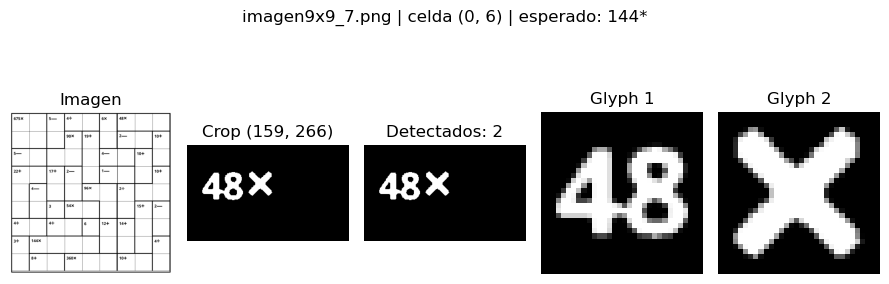

In [14]:
# Diagnóstico visual del caso que tenía 144* unido como 44.
plot_glyph_diagnostic('../dataset/images/9x9/imagen9x9_7.png', r=0, c=6, expected='144*')